 # Internet Usage in France (2009–2025)

 Exploring the MELODI API with `pynsee.melodi`:
 how did internet use evolve in France, and who is still left behind?

In [1]:
# ─── Imports ──────────────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import pandas as pd

from pynsee.melodi import get_catalog, get_dataset, get_range

# %matplotlib inline

# ─── Color palette ────────────────────────────────────────────────────────────
# Two-color system (teal + red) with grey variants: matches CC chart convention.
# Pattern (solid vs dashed) supplements color for accessibility.
TEAL     = "#1a6e8e"   # primary: age group lines / daily-use fill
LTEAL    = "#85bdd0"   # secondary: occasional-use fill (teal lightened)
RED      = "#c0392b"   # reference: national average / axis
CHARCOAL = "#2b2b2b"   # body text, direct labels
GREY     = "#888888"   # secondary text, reference labels
LGREY    = "#e5e5e5"   # non-user fill, grid lines

# ─── Global style ─────────────────────────────────────────────────────────────
plt.rcParams.update({
    "font.family":        "sans-serif",
    "font.size":          10,
    "axes.spines.top":    False,
    "axes.spines.right":  False,
    "axes.grid":          False,
    "figure.facecolor":   "white",
    "axes.facecolor":     "white",
    "axes.labelcolor":    CHARCOAL,
    "xtick.color":        GREY,
    "ytick.color":        GREY,
})

/home/onyxia/work/pynsee/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


 ## 1. Catalog

In [2]:
cat = get_catalog(language="en")
(
    cat[cat["dataset_identifier"] == "DS_TICM_PRATIQUES"]
    [["dataset_identifier", "title_en", "startPeriod", "endPeriod"]]
    .drop_duplicates("dataset_identifier")
)

,dataset_identifier,title_en,startPeriod,endPeriod
231,DS_TICM_PRATIQUES,Internet use of individuals,2009-01-01T00:00:00,2025-01-01T00:00:00


 ## 2. Available dimensions

In [3]:
dims_values = get_range("DS_TICM_PRATIQUES", language="en", include_values=True)

print(
    dims_values[dims_values["concept_code"] == "TICM_MEASURE"]
    [["code", "value_en"]]
    .to_string(index=False)
)

             code                                                                                                       value_en
      ACHA_12MOIS                          Percentage of individuals who made a purchase over the internet in the twelve months 
       ACHA_3MOIS                           Percentage of individuals who made a purchase over the internet in the three months 
      VENTE_3MOIS                               Percentage of individuals who made a sale over the internet in the three months 
  COMPTE_BANCAIRE                     Percentage of individuals who used banking services over the internet in the three months 
WEB_12MOIS_X_EGOV                  Rate of people using the internet during the year but without contact with the administration
      EGOV_12MOIS             Percentage of individuals who used administrative services over the internet in the twelve months 
        QUOTIDIEN                                 Percentage of individuals who used the internet

In [4]:
for concept in ["AGE", "SEX", "EDUC", "EMPSTA", "PCS_ESE"]:
    vals = dims_values[dims_values["concept_code"] == concept][["code", "value_en"]]
    print(f"\n── {concept} ({len(vals)} values) ──")
    print(vals.to_string(index=False))


── AGE (8 values) ──
  code              value_en
Y15T29   From 15 to 29 years
Y30T44   From 30 to 44 years
Y45T59   From 45 to 59 years
Y60T74   From 60 to 74 years
Y_GE75 75 years old or older
Y15T44   From 15 to 44 years
Y_GE60 60 years old or older
    _T                 Total

── SEX (3 values) ──
code value_en
   M     Male
   F   Female
  _T    Total

── EDUC (5 values) ──
   code                                                                               value_en
    0T1                                         Early childhood education or primary education
  2_353 Lower secondary education or Upper secondary education – French CAP, BEP or equivalent
3_X_353                                        Upper secondary education – French Baccalauréat
    4T8                                                  Diploma higher than the baccalaureate
     _T                                                                                  Total

── EMPSTA (2 values) ──
code        value_en


 ## 3. Load the dataset

 No dimension filter: we want all breakdowns to explore them in pandas.
 `OBS_STATUS == "A"` keeps definitive values only.

In [5]:
df_full = get_dataset("DS_TICM_PRATIQUES", language="en")
df_full = df_full[df_full["OBS_STATUS"] == "A"].copy()
df_full["TIME_PERIOD"] = df_full["TIME_PERIOD"].astype(int)

print(
    f"{len(df_full):,} observations: "
    f"{df_full['TICM_MEASURE'].nunique()} measures × "
    f"{df_full['TIME_PERIOD'].nunique()} years"
)

print(
    df_full.groupby("TICM_MEASURE")["TIME_PERIOD"]
    .agg(first_year="min", last_year="max", n_obs="count")
    .sort_values("n_obs", ascending=False)
)

6,118 observations: 16 measures × 16 years
                   first_year  last_year  n_obs
TICM_MEASURE                                   
ACHA_12MOIS              2009       2025    608
ACHA_3MOIS               2009       2025    608
COMPTE_BANCAIRE          2009       2025    608
EGOV_12MOIS              2009       2025    608
TEL_PAR_INT              2009       2025    608
WEB_3MOIS                2009       2025    608
QUOTIDIEN                2009       2025    608
PROFIL                   2009       2024    570
VENTE_3MOIS              2019       2025    228
LECTURE                  2019       2025    228
INFO_PRODUITS            2019       2025    228
EMAIL                    2019       2025    228
NO_EGOV                  2023       2025    114
NO_WEB_12MOIS            2023       2025    114
WEB_12MOIS_X_EGOV        2023       2025    114
RESEAUX_SOC              2025       2025     38


 ## 4. Exploratory analysis

 ### 4.1  Breakdown structure

In [6]:
# Check: each observation should vary on at most one socio-demographic dimension
# (mixed-marginal design, not a full cross-tabulation).
check = df_full[
    (df_full["TICM_MEASURE"] == "WEB_3MOIS") &
    (df_full["TIME_PERIOD"] == 2022)
][["SEX", "AGE", "EDUC", "EMPSTA", "PCS_ESE", "OBS_VALUE_NIVEAU"]]
print(check.sort_values(["SEX", "AGE"]).to_string())

      SEX     AGE     EDUC EMPSTA PCS_ESE  OBS_VALUE_NIVEAU
3262    F  Y15T44       _T     _T      _T              98.5
4198    F  Y45T59       _T     _T      _T              94.4
2836    F  Y_GE60       _T     _T      _T              62.9
331     F      _T       _T     _T      _T              84.8
3076    M  Y15T44       _T     _T      _T              97.9
2368    M  Y45T59       _T     _T      _T              92.4
2499    M  Y_GE60       _T     _T      _T              64.8
4437    M      _T       _T     _T      _T              85.9
2509   _T  Y15T29       _T     _T      _T              98.9
4530   _T  Y15T44      4T8     _T      _T              99.1
5301   _T  Y15T44    2_353     _T      _T              97.9
6786   _T  Y15T44      0T1     _T      _T              93.2
6992   _T  Y15T44       _T     _T      _T              98.2
7980   _T  Y15T44  3_X_353     _T      _T              99.5
6349   _T  Y30T44       _T     _T      _T              97.7
1150   _T  Y45T59    2_353     _T      _

 ### 4.2  National totals: which indicator grew most?

In [7]:
totals = df_full[
    (df_full["SEX"]    == "_T") & (df_full["AGE"]     == "_T") &
    (df_full["EDUC"]   == "_T") & (df_full["EMPSTA"]  == "_T") &
    (df_full["PCS_ESE"]== "_T")
].copy()

pivot = (
    totals
    .pivot(index="TIME_PERIOD", columns="TICM_MEASURE", values="OBS_VALUE_NIVEAU")
    .sort_index()
)

LONG_SERIES = ["WEB_3MOIS", "QUOTIDIEN", "ACHA_12MOIS", "ACHA_3MOIS",
               "COMPTE_BANCAIRE", "EGOV_12MOIS", "TEL_PAR_INT"]

delta = (pivot[LONG_SERIES].iloc[-1] - pivot[LONG_SERIES].iloc[0]).sort_values(ascending=False)
print("Change 2009 -> latest year (percentage points)\n")
print(delta.round(1).to_frame("Δ pp"))

Change 2009 -> latest year (percentage points)

                 Δ pp
TICM_MEASURE         
TEL_PAR_INT      46.6
EGOV_12MOIS      38.6
QUOTIDIEN        36.0
ACHA_3MOIS       34.8
ACHA_12MOIS      33.6
COMPTE_BANCAIRE  33.3
WEB_3MOIS        24.5


 ### 4.3  COVID effect: 2019 -> 2021

 The 2020 TIC-M survey was not conducted: the jump spans two years.

In [8]:
print(
    pivot[["WEB_3MOIS", "QUOTIDIEN", "ACHA_12MOIS", "EGOV_12MOIS"]]
    .loc[2017:2023]
    .round(1)
)
# COVID changed WHAT people do online more than WHETHER they go online:
# WEB_3MOIS +2.8 pp vs EGOV_12MOIS +6.2 pp and ACHA_12MOIS +5.0 pp (2019->2021).

TICM_MEASURE  WEB_3MOIS  QUOTIDIEN  ACHA_12MOIS  EGOV_12MOIS
TIME_PERIOD                                                 
2017               80.5       64.8         60.7         61.4
2018               82.0       69.3         60.9         64.6
2019               83.3       71.4         64.1         67.9
2021               86.1       72.3         69.1         74.1
2022               85.3       76.6         69.5         76.2
2023               86.8       77.7         70.1         77.4


 ### 4.4  The age gap

In [9]:
AGE_FINE   = ["Y15T29", "Y30T44", "Y45T59", "Y60T74", "Y_GE75"]
AGE_LABELS = {
    "Y15T29": "15–29",  "Y30T44": "30–44",  "Y45T59": "45–59",
    "Y60T74": "60–74",  "Y_GE75": "75+",
}

web_age = df_full[
    (df_full["TICM_MEASURE"] == "WEB_3MOIS") &
    (df_full["AGE"].isin(AGE_FINE)) &
    (df_full["SEX"]    == "_T") & (df_full["EDUC"]    == "_T") &
    (df_full["EMPSTA"] == "_T") & (df_full["PCS_ESE"] == "_T")
].sort_values(["AGE", "TIME_PERIOD"])

pivot_age = (
    web_age
    .pivot(index="TIME_PERIOD", columns="AGE", values="OBS_VALUE_NIVEAU")
    [AGE_FINE]
)
print(pivot_age.round(1).to_string())

gap = pivot_age["Y15T29"] - pivot_age["Y_GE75"]
print(
    f"\nGap 15–29 vs 75+: "
    f"{gap.iloc[0]:.0f} pp in {gap.index[0]} -> "
    f"{gap.iloc[-1]:.0f} pp in {gap.index[-1]}"
)

AGE          Y15T29  Y30T44  Y45T59  Y60T74  Y_GE75
TIME_PERIOD                                        
2009           93.8    80.7    68.8    37.6     7.8
2010           98.0    86.9    72.2    39.8     9.0
2011           92.0    90.2    75.9    49.0    13.3
2012           97.7    91.7    81.6    51.7    16.3
2013           96.6    92.1    81.7    55.2    16.6
2014           97.1    93.4    82.3    60.7    21.1
2015           97.6    93.1    86.4    60.7    21.0
2016           97.3    94.9    85.8    64.4    24.3
2017           97.5    95.0    88.9    64.7    28.4
2018           97.2    95.9    89.5    70.6    29.7
2019           96.9    96.6    90.4    73.6    32.2
2021           97.7    96.4    94.8    78.7    40.8
2022           98.9    97.7    93.4    74.0    43.3
2023           97.8    98.1    94.3    81.5    42.0
2024           98.6    97.8    94.7    86.1    48.3
2025           99.0    98.4    95.9    86.9    51.1

Gap 15–29 vs 75+: 86 pp in 2009 -> 48 pp in 2025


 ### 4.5  The education divide within seniors

In [10]:
EDUC_LABELS = {
    "0T1":     "No diploma / primary",
    "2_353":   "Vocational / lower secondary",
    "3_X_353": "Upper secondary (baccalauréat)",
    "4T8":     "Higher education",
}

web_educ_seniors = df_full[
    (df_full["TICM_MEASURE"] == "WEB_3MOIS") &
    (df_full["AGE"]    == "Y_GE60") &
    (df_full["EDUC"].isin(EDUC_LABELS.keys())) &
    (df_full["SEX"]    == "_T") &
    (df_full["EMPSTA"] == "_T") &
    (df_full["PCS_ESE"]== "_T")
].sort_values("TIME_PERIOD")

latest = web_educ_seniors["TIME_PERIOD"].max()
print(f"Education gap among 60+ in {latest}:")
print(
    web_educ_seniors[web_educ_seniors["TIME_PERIOD"] == latest]
    [["EDUC", "OBS_VALUE_NIVEAU"]]
    .assign(education=lambda d: d["EDUC"].map(EDUC_LABELS))
    .set_index("education")[["OBS_VALUE_NIVEAU"]]
    .rename(columns={"OBS_VALUE_NIVEAU": "% using internet"})
    .round(1)
)
# -> ~50 pp gap between no diploma (39.6%) and higher education (90.0%).
# Education is a stronger predictor than age alone.

Education gap among 60+ in 2025:
                                % using internet
education                                       
Higher education                            95.4
No diploma / primary                        49.1
Vocational / lower secondary                77.9
Upper secondary (baccalauréat)              88.3


 ## 5. Charts


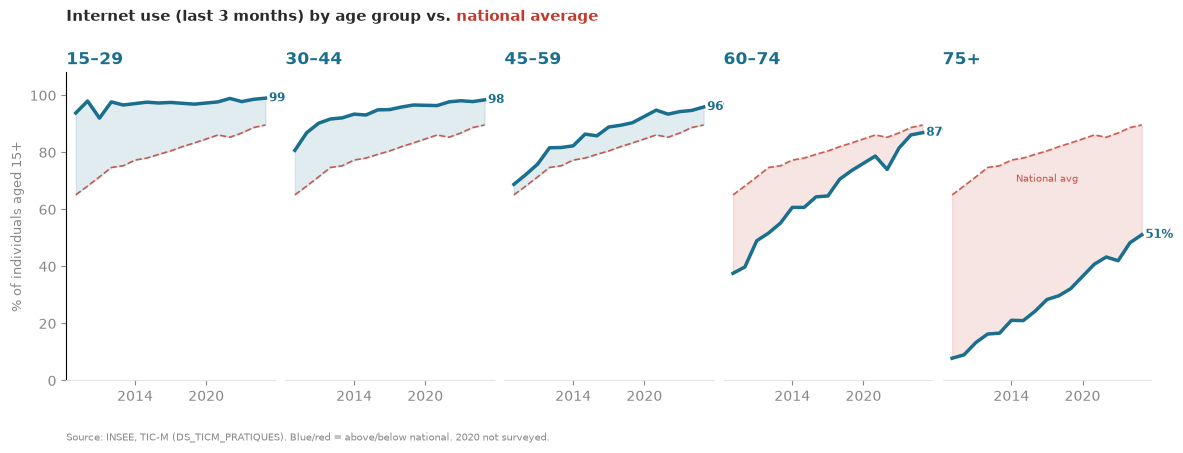

In [13]:
from matplotlib.offsetbox import AnchoredOffsetbox, HPacker, TextArea

national = pivot["WEB_3MOIS"].dropna()
fig, axes = plt.subplots(1, 5, figsize=(14, 4), sharey=True)
fig.subplots_adjust(wspace=0.05)

for ax, age in zip(axes, AGE_FINE):
    s = pivot_age[age].dropna()
    yrs = s.index.intersection(national.index)
    s, n, x = s[yrs].values, national[yrs].values, yrs.values

    ax.fill_between(x, n, s, where=s >= n, color=TEAL, alpha=0.13, interpolate=True)
    ax.fill_between(x, n, s, where=s < n,  color=RED,  alpha=0.13, interpolate=True)
    ax.plot(x, n, color=RED, lw=1.2, ls="--", alpha=0.8)
    ax.plot(x, s, color=TEAL, lw=2.5)
    ax.text(x[-1] + 0.3, s[-1], f"{s[-1]:.0f}%", fontsize=8.5,
            color=TEAL, va="center", fontweight="bold", clip_on=False)
    ax.set_title(AGE_LABELS[age], fontweight="bold", loc="left", color=TEAL, pad=6)
    ax.set_ylim(0, 108)
    ax.xaxis.set_major_locator(mticker.MaxNLocator(nbins=3, integer=True, prune="both"))
    ax.spines["bottom"].set_color(LGREY)
    if ax is axes[0]:
        ax.set_ylabel("% of individuals aged 15+", fontsize=9, color=GREY)
    else:
        ax.spines["left"].set_visible(False)
        ax.tick_params(left=False)

mid = len(national) // 2
axes[-1].text(national.index[mid], national.iloc[mid] - 8, "National avg",
              fontsize=7.5, color=RED, ha="center", va="top", alpha=0.85)

x0 = axes[0].get_position().x0
tp = dict(fontweight="bold", fontsize=11)
title = HPacker(align="baseline", pad=0, sep=0, children=[
    TextArea("Internet use (last 3 months) by age group vs. ", textprops={**tp, "color": CHARCOAL}),
    TextArea("national average", textprops={**tp, "color": RED}),
])
fig.add_artist(AnchoredOffsetbox(
    loc="lower left", child=title, frameon=False, pad=0, borderpad=0,
    bbox_to_anchor=(x0, 1.0), bbox_transform=fig.transFigure))

fig.text(x0, -0.04,
         "Source: INSEE, TIC-M (DS_TICM_PRATIQUES). Blue/red = above/below national. 2020 not surveyed.",
         fontsize=7.5, color=GREY)
plt.savefig("chart1_age_groups_vs_national.png", dpi=150, bbox_inches="tight")
plt.show()

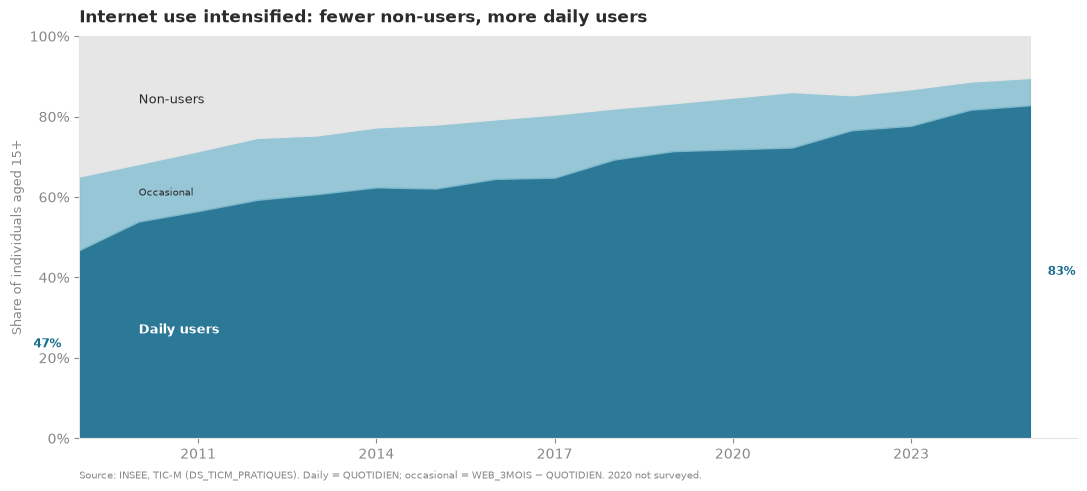

In [12]:
yrs   = pivot.index[pivot[["WEB_3MOIS", "QUOTIDIEN"]].notna().all(axis=1)]
x     = yrs.values
web   = pivot.loc[yrs, "WEB_3MOIS"].values
daily = pivot.loc[yrs, "QUOTIDIEN"].values

fig, ax = plt.subplots(figsize=(11, 5))
ax.fill_between(x, 0,     daily, color=TEAL,  alpha=0.92)
ax.fill_between(x, daily, web,   color=LTEAL, alpha=0.85)
ax.fill_between(x, web,   100,   color=LGREY, alpha=0.95)

# band labels replace the legend, placed on the second year
ax.text(x[1], daily[1] / 2,                   "Daily users", color="white",
        fontweight="bold", fontsize=9, va="center")
ax.text(x[1], (daily[1] + web[1]) / 2,        "Occasional",  color=CHARCOAL,
        fontsize=7.5, va="center")
ax.text(x[1], (web[1] + 100) / 2,             "Non-users",   color=CHARCOAL,
        fontsize=9, va="center")

# the story: daily-user share at both ends
for xi, d, ha, off in [(x[0], daily[0], "right", -0.3), (x[-1], daily[-1], "left", 0.3)]:
    ax.text(xi + off, d / 2, f"{d:.0f}%", color=TEAL, fontweight="bold",
            fontsize=8.5, ha=ha, va="center", clip_on=False)

ax.set_ylim(0, 100)
ax.set_xlim(x[0], x[-1] + 0.8)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{v:.0f}%"))
ax.yaxis.set_major_locator(mticker.MultipleLocator(20))
ax.xaxis.set_major_locator(mticker.MaxNLocator(integer=True, nbins=8))
ax.spines["left"].set_color(LGREY)
ax.spines["bottom"].set_color(LGREY)
ax.set_ylabel("Share of individuals aged 15+", fontsize=9, color=GREY)
ax.set_title("Internet use intensified: fewer non-users, more daily users",
             fontweight="bold", fontsize=12, loc="left", pad=10, color=CHARCOAL)
ax.text(0, -0.10, "Source: INSEE, TIC-M (DS_TICM_PRATIQUES). Daily = QUOTIDIEN; "
        "occasional = WEB_3MOIS − QUOTIDIEN. 2020 not surveyed.",
        transform=ax.transAxes, fontsize=7.5, color=GREY)
plt.tight_layout()
plt.savefig("chart2_usage_composition.png", dpi=150, bbox_inches="tight")
plt.show()